<a href="https://colab.research.google.com/github/yashcodes1205/IPL-Data-Analysis/blob/main/IPL_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🏏 IPL DATA ANALYSIS

# 🎯PROJECT GOALS
The goal of this project is to analyze IPL (Indian Premier League) matches dataset to uncover trends, patterns, and insights.
We will use NumPy, Pandas, Matplotlib & Seaborn for data analysis and generate meaningful insights about teams, toss decisions, venues, and players.
This is a beginner-friendly project without machine learning but gives a complete real-world sports analytics experience.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.style.use('fivethirtyeight')

In [2]:
deliveries = pd.read_csv('deliveries.csv')

In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
ipl = pd.read_csv('matches.csv',low_memory=False)

In [5]:
ipl.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


# **📊 Dataset Overview**

Let’s understand the structure of the dataset.

In [6]:
deliveries.shape

(260920, 17)

In [7]:
ipl.shape

(1095, 20)

In [8]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [9]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [10]:
ipl['team1'].value_counts()

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


In [11]:
ipl['team2'].value_counts()

,count
team2,
Mumbai Indians,138
Kolkata Knight Riders,130
Rajasthan Royals,120
Chennai Super Kings,110
Royal Challengers Bangalore,105
Kings XI Punjab,98
Sunrisers Hyderabad,96
Delhi Daredevils,76
Delhi Capitals,50


In [12]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Kolkata Knight Riders,29514
Chennai Super Kings,28651
Royal Challengers Bangalore,28205
Rajasthan Royals,26242
Kings XI Punjab,22646
Sunrisers Hyderabad,21843
Delhi Daredevils,18786
Delhi Capitals,10946


In [13]:
deliveries['bowling_team'].value_counts()

,count
bowling_team,
Mumbai Indians,31505
Kolkata Knight Riders,29663
Chennai Super Kings,28576
Royal Challengers Bangalore,28358
Rajasthan Royals,26432
Kings XI Punjab,22483
Sunrisers Hyderabad,21717
Delhi Daredevils,18725
Delhi Capitals,11216


# **🧹Data Cleaning: Standardizing Team Names**

During the Exploratory Data Analysis (EDA) phase, inconsistencies were identified in the naming conventions of certain franchises. These occur primarily due to rebranding or minor clerical errors in the raw dataset:


*   Rising Pune Supergiant(s): The team operated under slightly different names across the 2016 and 2017 seasons. These have been unified to Rising Pune Supergiant
*  Delhi Capitals / Delhi Daredevils: In 2019, the Delhi Daredevils franchise was rebranded as the Delhi Capitals.
*   Royal Challengers Bangalore / Bengaluru: In 2024, the franchise officially updated its name from Royal Challengers Bangalore to Royal Challengers Bengaluru.











In [14]:
team_corrections = {
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}

# Applying the fix to the dataframe
target_columns = ['team1', 'team2', 'winner', 'toss_winner']

for col in target_columns:
    ipl[col] = ipl[col].replace(team_corrections)

In [15]:
team_corrections = {
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Delhi Daredevils': 'Delhi Capitals',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Kings XI Punjab': 'Punjab Kings'
}

target_columns = ['batting_team', 'bowling_team']

for col in target_columns:
    deliveries[col] = deliveries[col].replace(team_corrections)

In [16]:
ipl['winner'].value_counts()

,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bengaluru,123
Delhi Capitals,115
Punjab Kings,112
Rajasthan Royals,112
Sunrisers Hyderabad,88
Deccan Chargers,29


In [17]:
deliveries['batting_team'].value_counts()

,count
batting_team,
Mumbai Indians,31437
Royal Challengers Bengaluru,30023
Delhi Capitals,29732
Kolkata Knight Riders,29514
Punjab Kings,29479
Chennai Super Kings,28651
Rajasthan Royals,26242
Sunrisers Hyderabad,21843
Deccan Chargers,9034


In [18]:
ipl['city'].isna().sum()

np.int64(51)

In [19]:
ipl['method'].value_counts()

,count
method,
D/L,21


In [20]:
ipl['city'] = ipl['city'].fillna('Unknown')
ipl['method'] = ipl['method'].fillna('NON D/L')

# **🔍MATCHES PER SEASON**

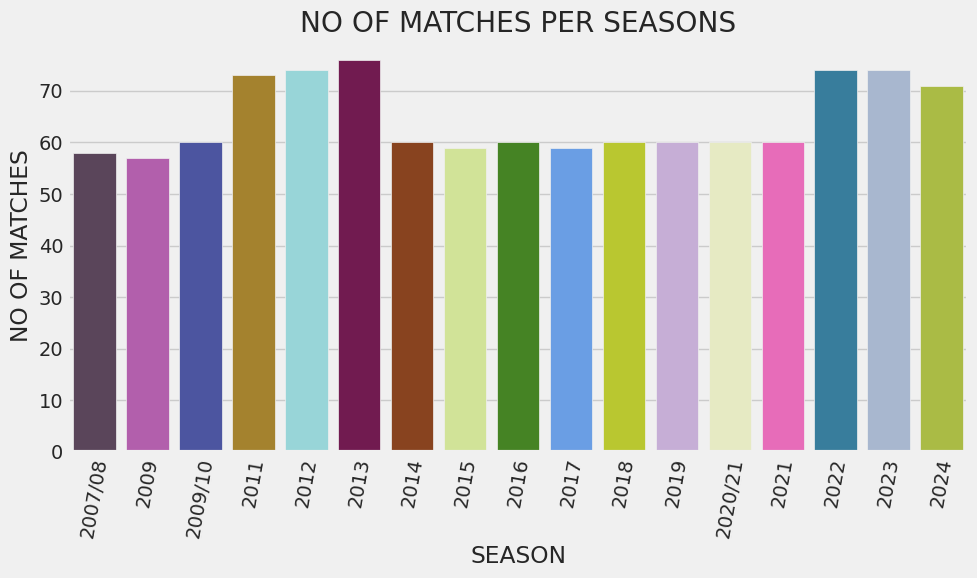

In [21]:
No_of_matches = ipl['season'].value_counts().sort_index()
No_of_matches

def random_colors(no_of_colors):
  return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)])for _ in range(no_of_colors)]

plt.figure(figsize=(10,6))
sns.barplot(
    x=No_of_matches.index,
    y=No_of_matches.values ,
    hue=No_of_matches.index,
    palette=random_colors(len(No_of_matches)),
    legend=False
)
plt.title('NO OF MATCHES PER SEASONS')
plt.xlabel('SEASON')
plt.ylabel('NO OF MATCHES')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

# **SUCCESS RATE OF TEAMS**

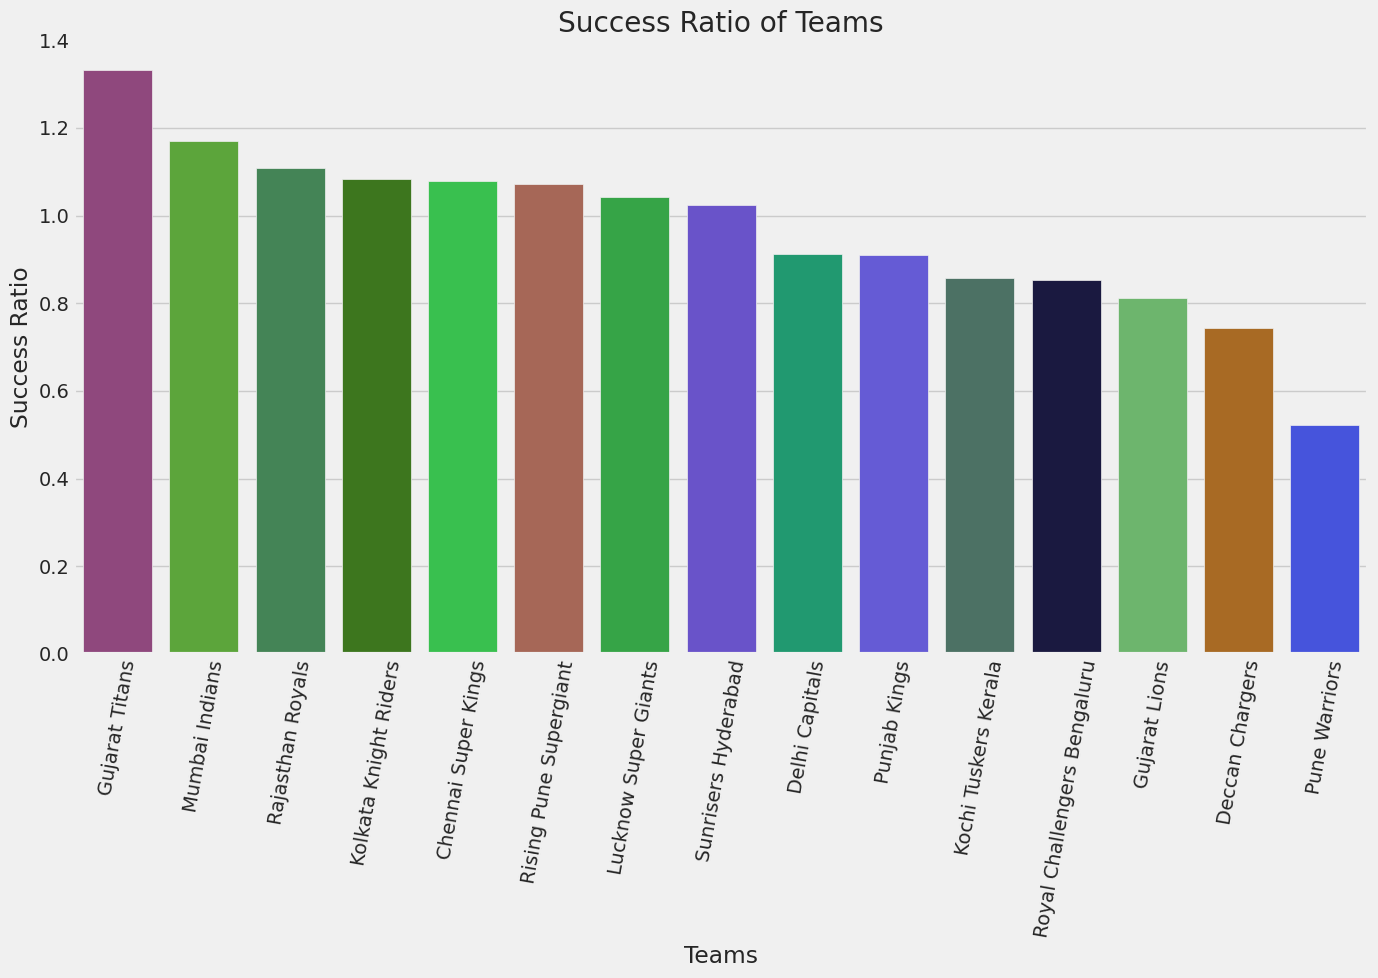

In [22]:
Success_ratio = ipl.groupby('winner').count()['id']/ipl.groupby('team1').count()['id']
Success_ratio_dec = Success_ratio.sort_values(ascending=False)

def random_colors(no_of_colors):
  return ['#'+''.join([np.random.choice(list('0123456789ABCDEF')) for _ in range(6)])for _ in range(no_of_colors)]

plt.figure(figsize=(14,10))
sns.barplot(
    x=Success_ratio_dec.index,
    y=Success_ratio_dec.values ,
    hue=Success_ratio_dec.index,  # Assigning x to hue
    palette=random_colors(len(Success_ratio_dec)),
    legend=False            # Hiding the legend as requested by the warning
)
plt.title('Success Ratio of Teams')
plt.xlabel('Teams')
plt.ylabel('Success Ratio')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

# **🏆MOST TITLES WON**

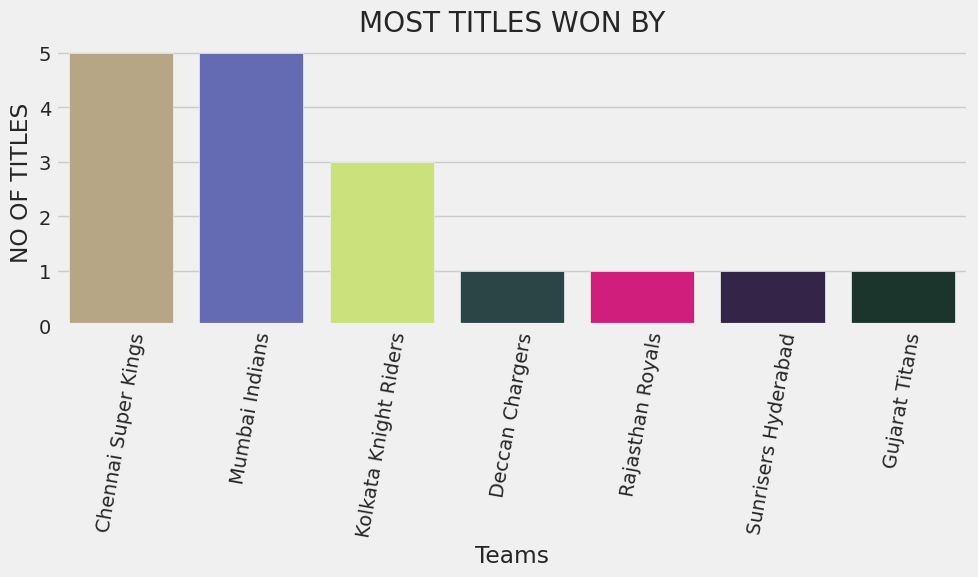

In [23]:
most_titles = ipl.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=most_titles.index,
    y=most_titles.values,
    hue=most_titles.index,  # Assigning x to hue
    palette=random_colors(len(most_titles)),
    legend=False            # Hiding the legend as requested by the warning
)
plt.title('MOST TITLES WON BY')
plt.xlabel('Teams')
plt.ylabel('NO OF TITLES')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

# **🏏TOP 10 PLAYERS WITH MOST RUNS**

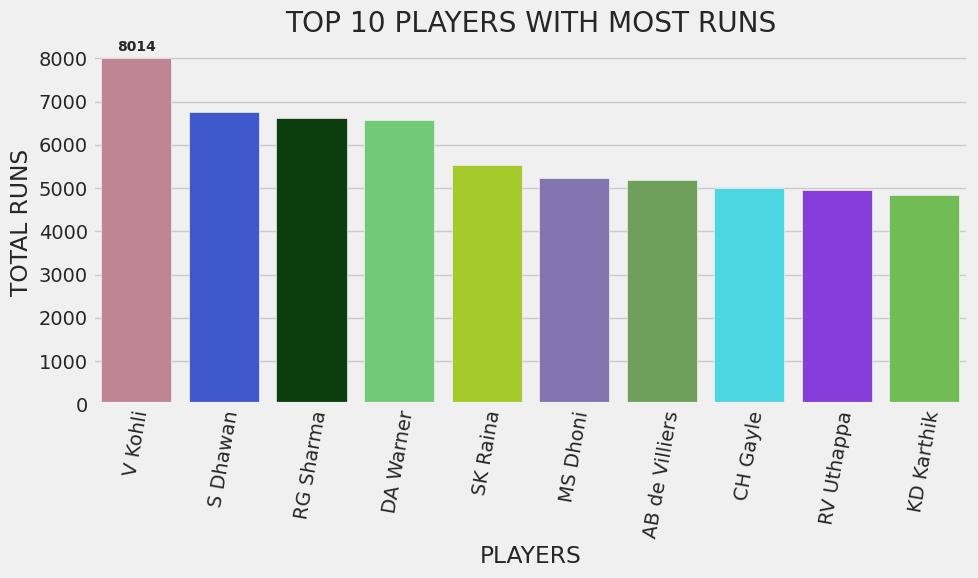

In [24]:
total_runs = deliveries.groupby('batter')['batsman_runs'].sum().reset_index(name='Runs')
top_batsman = total_runs.sort_values(by='Runs', ascending=False).head(10)

plt.figure(figsize=(10,6))
ax=sns.barplot(
    x='batter',
    y='Runs',
    data=top_batsman,
    hue='batter',  # Assigning x variable ('batter') to hue
    palette=random_colors(len(top_batsman)),
    legend=False            # Hiding the legend as requested by the warning
)
ax.bar_label(ax.containers[0], padding=3, fontsize=10, fontweight='bold')
plt.title('TOP 10 PLAYERS WITH MOST RUNS')
plt.xlabel('PLAYERS')
plt.ylabel('TOTAL RUNS')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

In [25]:
top_batsman

,batter,Runs
631,V Kohli,8014
512,S Dhawan,6769
477,RG Sharma,6630
147,DA Warner,6567
546,SK Raina,5536
374,MS Dhoni,5243
30,AB de Villiers,5181
124,CH Gayle,4997
501,RV Uthappa,4954
282,KD Karthik,4843


# **TOP 10 BEST PERFORMANCE BY BATTER TILL IPL 2024**

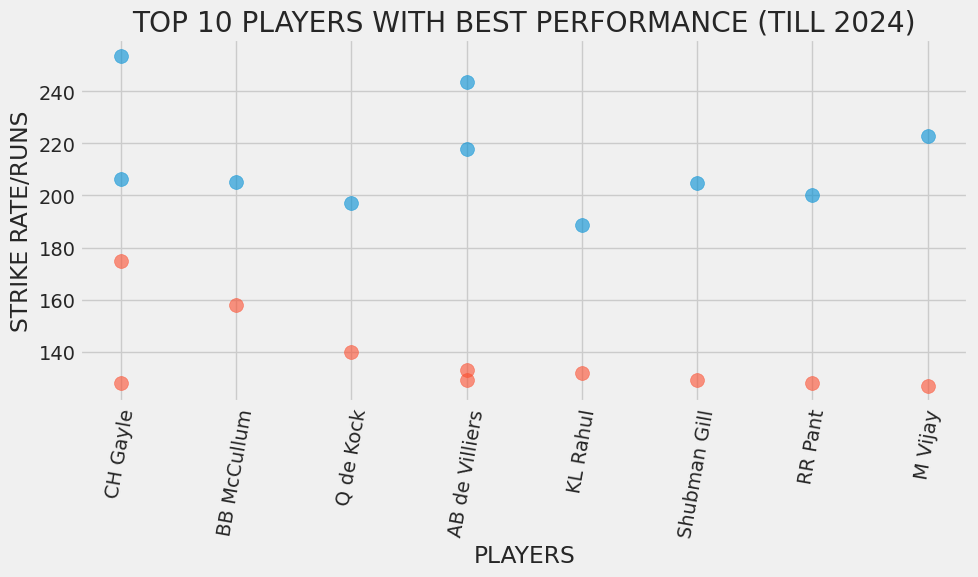

In [26]:
batter_runs = deliveries.groupby(['match_id','batter'])['batsman_runs'].sum().reset_index(name='Innings Runs')
top_scores_batsman = batter_runs.sort_values(by = 'Innings Runs', ascending=False).head(10)
total_ball_faced = deliveries.groupby(['match_id','batter'])['batsman_runs'].count().reset_index(name='Total Balls Faced')

batsman_performance = pd.merge(top_scores_batsman,total_ball_faced,on=['match_id','batter'])
batsman_performance['Strike Rate for Match'] = np.round(batsman_performance['Innings Runs']*100/batsman_performance['Total Balls Faced'],2)

plt.figure(figsize=(10,6))
plt.scatter(batsman_performance['batter'],batsman_performance['Strike Rate for Match'], label='Strike Rate', s=100 , alpha=0.6)
plt.scatter(batsman_performance['batter'],batsman_performance['Innings Runs'], label='Runs', s=100 , alpha=0.6)
plt.title('TOP 10 PLAYERS WITH BEST PERFORMANCE (TILL 2024)')
plt.xlabel('PLAYERS')
plt.ylabel('STRIKE RATE/RUNS')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

In [27]:
batsman_performance

,match_id,batter,Innings Runs,Total Balls Faced,Strike Rate for Match
0,598027,CH Gayle,175,69,253.62
1,335982,BB McCullum,158,77,205.19
2,1304112,Q de Kock,140,71,197.18
3,829795,AB de Villiers,133,61,218.03
4,1216510,KL Rahul,132,70,188.57
5,1370352,Shubman Gill,129,63,204.76
6,980987,AB de Villiers,129,53,243.40
7,548372,CH Gayle,128,62,206.45
8,1136602,RR Pant,128,64,200.00
9,419137,M Vijay,127,57,222.81


# **TOP 10 BOWLERS TILL IPL 2024**

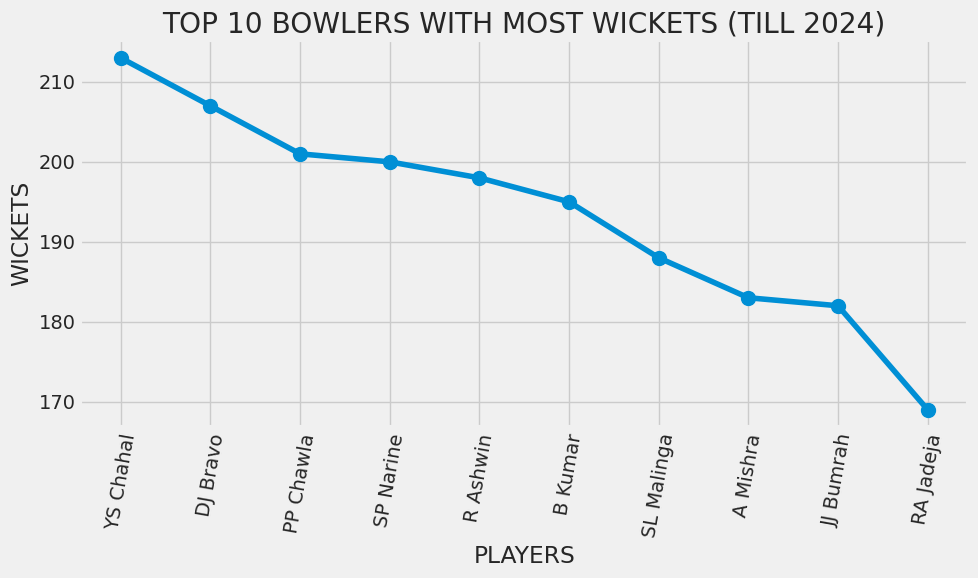

In [28]:
bowling_wkt = deliveries[deliveries['dismissal_kind'] != 'run out']
bowler_wkt = deliveries.groupby('bowler')['dismissal_kind'].count().reset_index(name='Wickets')
top_wkt_taker = bowler_wkt.sort_values(by='Wickets',ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.plot(top_wkt_taker['bowler'],top_wkt_taker['Wickets'], marker='o',ms=10)
plt.title('TOP 10 BOWLERS WITH MOST WICKETS (TILL 2024)')
plt.xlabel('PLAYERS')
plt.ylabel('WICKETS')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

In [29]:
top_wkt_taker

,bowler,Wickets
524,YS Chahal,213
119,DJ Bravo,207
348,PP Chawla,201
446,SP Narine,200
355,R Ashwin,198
71,B Kumar,195
438,SL Malinga,188
8,A Mishra,183
193,JJ Bumrah,182
373,RA Jadeja,169


# **🥎TOP 10 BEST BOWLING PERFORMANCE**

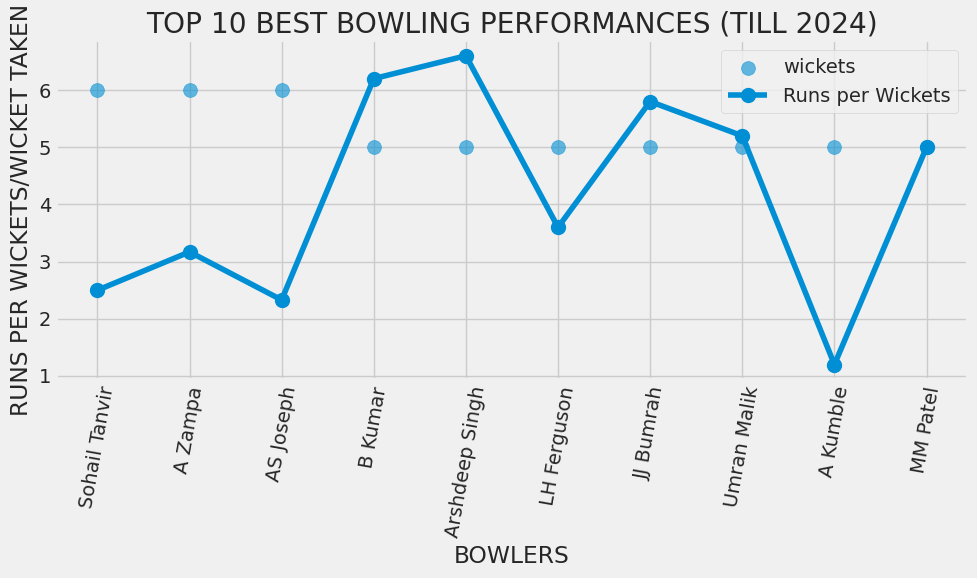

In [30]:
match_bowling_top = bowling_wkt.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index(
    name = 'wickets').sort_values(by='wickets',ascending=False).head(10)
match_bowler_runs = deliveries.groupby(['match_id','bowler'])['total_runs'].sum().reset_index(name='Runs Conceded')
match_bowler_performance = pd.merge(match_bowling_top,match_bowler_runs,how='inner',on=['match_id','bowler'])
match_bowler_performance['Runs per Wickets'] = np.round(match_bowler_performance['Runs Conceded']/match_bowler_performance['wickets'],2)

plt.figure(figsize=(10,6))
plt.scatter(match_bowler_performance['bowler'],match_bowler_performance['wickets'],label='wickets',s=100,alpha=0.6)
plt.plot(match_bowler_performance['bowler'],match_bowler_performance['Runs per Wickets'], marker='o',ms=10,label='Runs per Wickets')
plt.title('TOP 10 BEST BOWLING PERFORMANCES (TILL 2024)')
plt.xlabel('BOWLERS')
plt.ylabel('RUNS PER WICKETS/WICKET TAKEN')
plt.legend()
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()


In [31]:
match_bowler_performance

,match_id,bowler,wickets,Runs Conceded,Runs per Wickets
0,336005,Sohail Tanvir,6,15,2.50
1,980979,A Zampa,6,19,3.17
2,1178394,AS Joseph,6,14,2.33
3,1359536,B Kumar,5,31,6.20
4,1254111,Arshdeep Singh,5,33,6.60
5,1216512,LH Ferguson,5,18,3.60
6,1216517,JJ Bumrah,5,29,5.80
7,1304086,Umran Malik,5,26,5.20
8,392182,A Kumble,5,6,1.20
9,501251,MM Patel,5,25,5.00


# **🏙️TOP 10 CITIES BY NUMBER OF MATCHES**

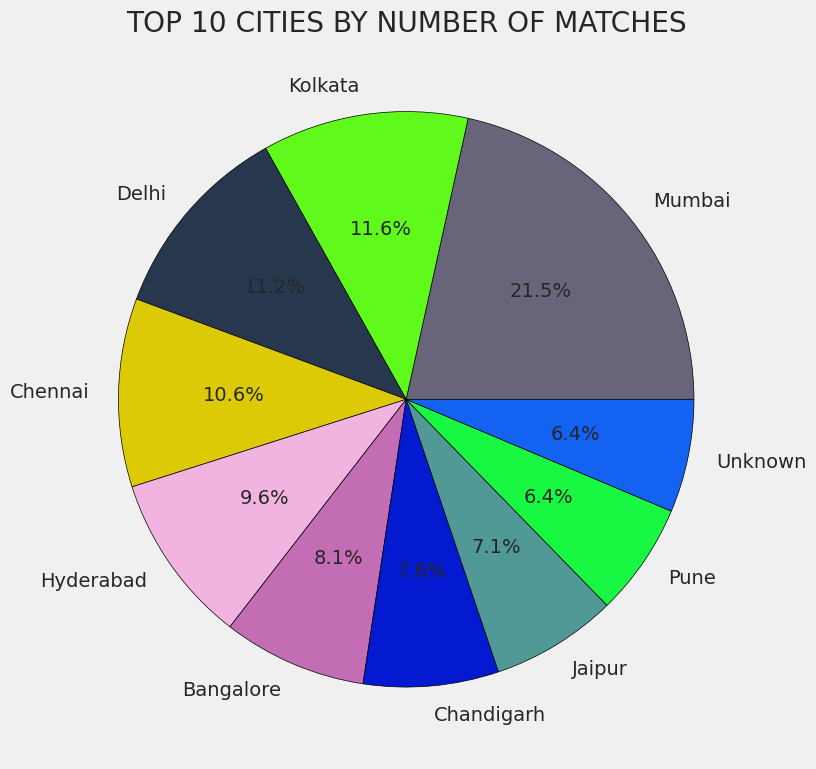

In [32]:
top_cities = ipl['city'].value_counts().reset_index(name='Match Count')[:10]

plt.figure(figsize=(8,8))
plt.pie(top_cities['Match Count'] , labels=top_cities['city'],colors = random_colors(10),
        autopct='%1.1f%%',wedgeprops=dict(edgecolor='black'))
plt.title('TOP 10 CITIES BY NUMBER OF MATCHES')
plt.tight_layout()
plt.show()

# **TYPE OF DISMISSALS**

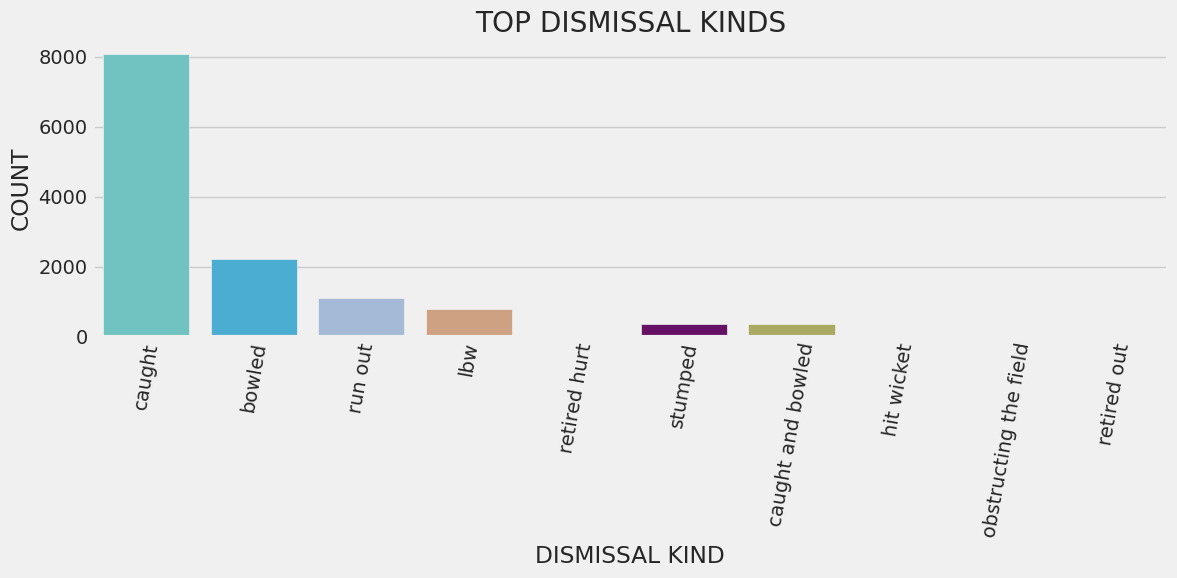

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(x='dismissal_kind', data=deliveries, hue='dismissal_kind', palette=random_colors(len(deliveries['dismissal_kind'].value_counts())), legend=False)
plt.title('TOP DISMISSAL KINDS')
plt.xlabel('DISMISSAL KIND')
plt.ylabel('COUNT')
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

# **TOP 10 FIELDERS**

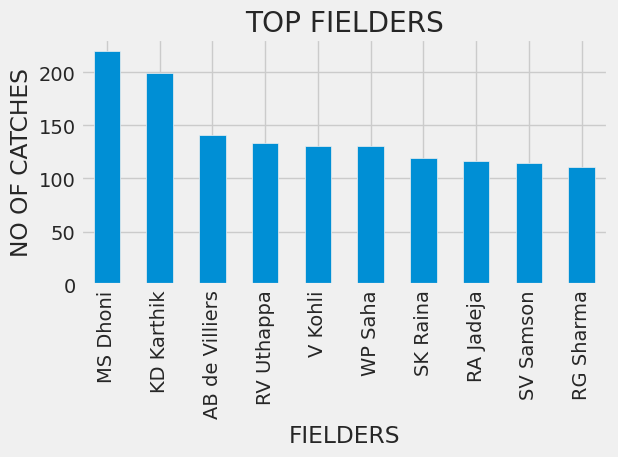

In [34]:
deliveries['fielder'].value_counts()[:10].plot(kind='bar',xlabel='FIELDERS',ylabel='NO OF CATCHES')
plt.title('TOP FIELDERS')
plt.tight_layout()
plt.show()

# **ANALYSIS OVER BY OVER**

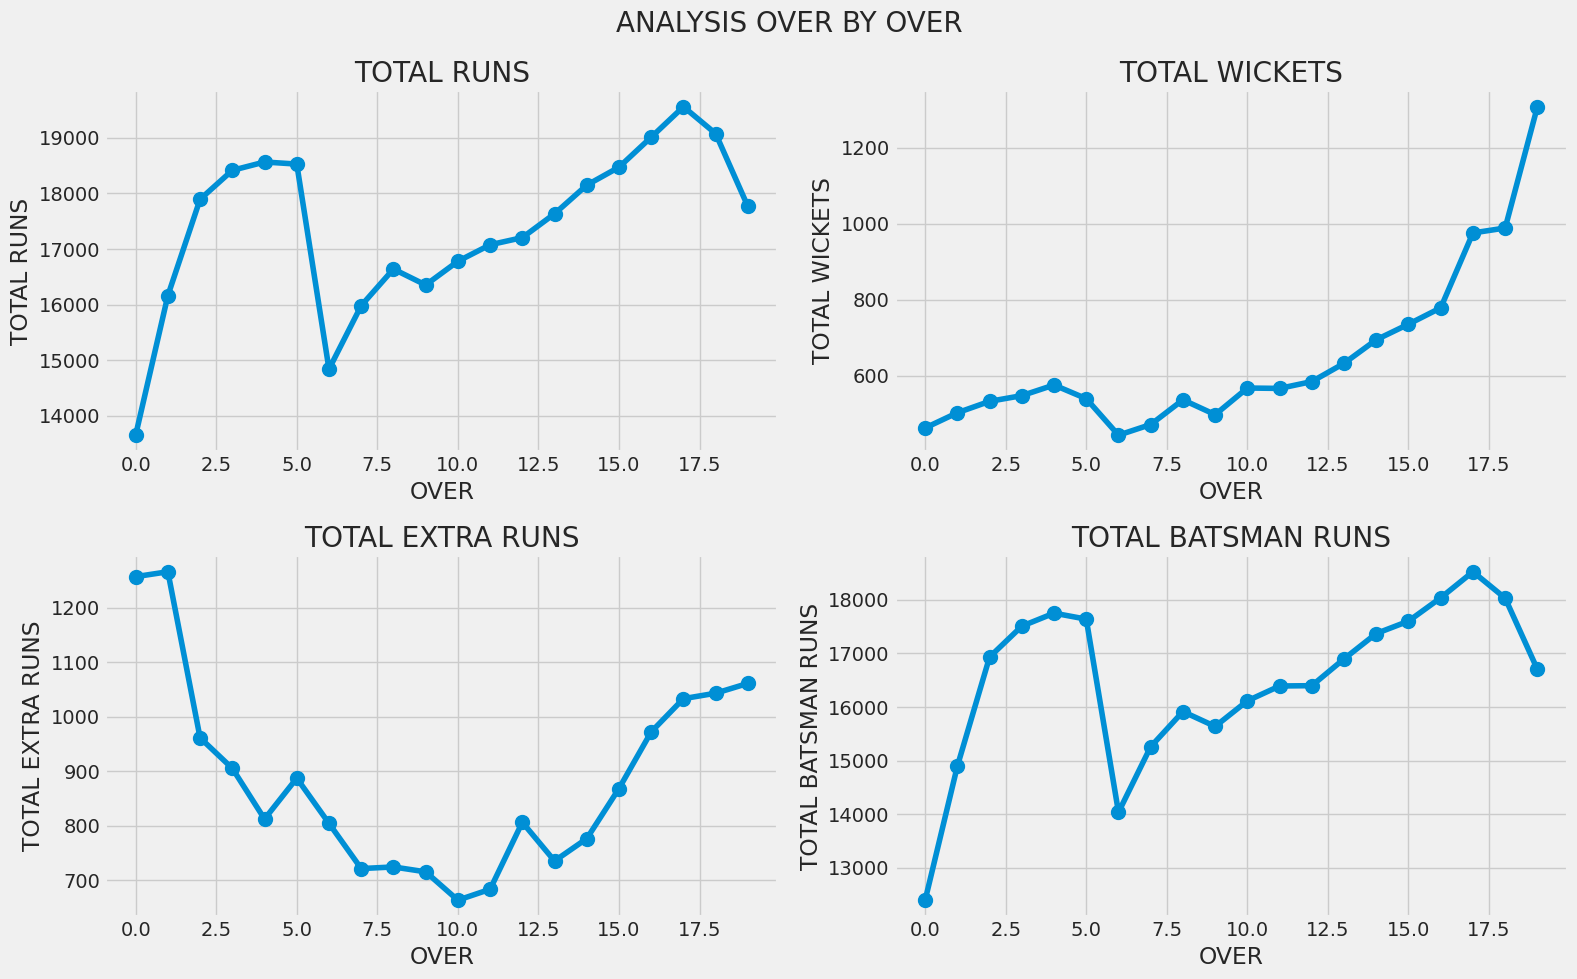

In [35]:
from matplotlib import axes
over_summary = deliveries.groupby('over')[['total_runs','is_wicket','extra_runs','batsman_runs']].sum()

fig,axes = plt.subplots(2,2,figsize=(16,10))
fig.suptitle('ANALYSIS OVER BY OVER',fontsize=20)

axes[0,0].plot(over_summary.index,over_summary['total_runs'],marker='o',ms=10,label='Total Runs')
axes[0,0].set_title('TOTAL RUNS')
axes[0,0].set_xlabel('OVER')
axes[0,0].set_ylabel('TOTAL RUNS')

axes[0,1].plot(over_summary.index,over_summary['is_wicket'],marker='o',ms=10,label='Total Wickets')
axes[0,1].set_title('TOTAL WICKETS')
axes[0,1].set_xlabel('OVER')
axes[0,1].set_ylabel('TOTAL WICKETS')

axes[1,0].plot(over_summary.index,over_summary['extra_runs'],marker='o',ms=10,label='Total Extra Runs')
axes[1,0].set_title('TOTAL EXTRA RUNS')
axes[1,0].set_xlabel('OVER')
axes[1,0].set_ylabel('TOTAL EXTRA RUNS')

axes[1,1].plot(over_summary.index,over_summary['batsman_runs'],marker='o',ms=10,label='Total Batsman Runs')
axes[1,1].set_title('TOTAL BATSMAN RUNS')
axes[1,1].set_xlabel('OVER')
axes[1,1].set_ylabel('TOTAL BATSMAN RUNS')

plt.tight_layout()
plt.show()



# **TOSS DECISION**

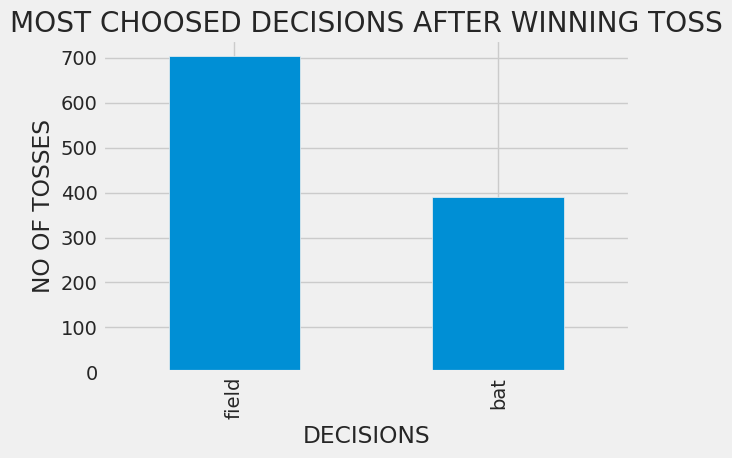

In [36]:
ipl['toss_decision'].value_counts()[:10].plot(kind='bar',xlabel='DECISIONS',ylabel='NO OF TOSSES')
plt.title('MOST CHOOSED DECISIONS AFTER WINNING TOSS')
plt.tight_layout()
plt.show()

# **🎲 Toss Decisions – Does winning toss matter?**

In [37]:
toss_match = (ipl['toss_winner'] == ipl['winner']).sum()
toss_match

np.int64(554)

In [38]:
total_matches = ipl.shape[0]
round((toss_match/total_matches)*100)

51

# **⭐ Player of the Match Analysist**

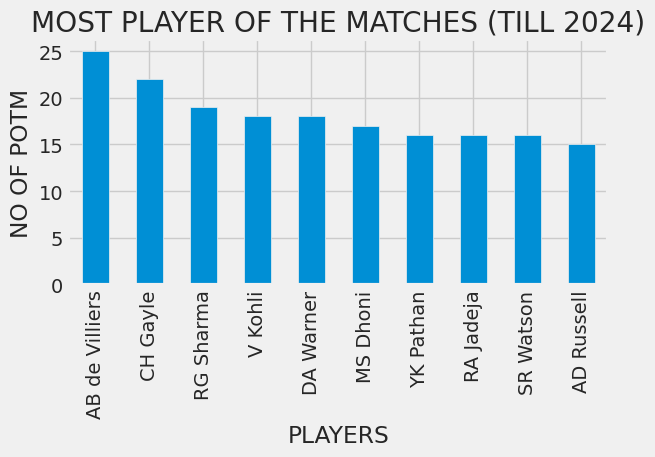

In [39]:
ipl['player_of_match'].value_counts()[:10].plot(kind='bar',xlabel='PLAYERS',ylabel='NO OF POTM')
plt.title('MOST PLAYER OF THE MATCHES (TILL 2024)')
plt.tight_layout()
plt.show()

# **🏁 Conclusion**

This data analysis project on the IPL dataset (2008–2024) provides a comprehensive overview of the league's evolution and the factors that define success in T20 cricket. Through data cleaning, transformation, and visualization, several key insights were uncovered:

*   Franchise Dominance: The analysis of "Most Titles" and "Success Ratios" confirms that teams like Mumbai Indians and Chennai Super Kings have maintained the highest levels of consistency, even when accounting for rebranding and the addition of new franchises.
*   Individual Excellence: The "Top Run Scorers" and "Leading Wicket Takers" charts highlight the longevity and impact of players like Virat Kohli and Yuzvendra Chahal. The "Best Performance" scatter plots further illustrate that high-impact innings (high strike rates) are as crucial as total run accumulation.

*   The "Toss" Myth: Interestingly, the data shows that winning the toss results in a match win only approximately 51% of the time. This suggests that while the toss provides a strategic starting advantage, match outcome is more heavily dictated by on-field execution and team depth.
*   Data Integrity: A critical part of this project involved Data Standardization. By merging rebranded teams (e.g., Delhi Daredevils to Delhi Capitals), we ensured that historical records accurately reflect the continuous legacy of these franchises rather than splitting their achievements.



